### Libraries

In [93]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.metrics import PrecisionRecallDisplay

### Load Dataset

In [70]:
# Load Data
df_original = pd.read_csv('df.csv')
df_original['Malnurished'] = df_original[['Underweight', 'Stunting', 'Wasting']].max(axis=1)
df = df_original.drop(['Underweight', 'Stunting', 'Wasting'], axis = 1)

# Train-test Split
X = df.drop(columns=['Malnurished'])
y = df['Malnurished']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify = y, random_state = 42)

In [71]:
print(df.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(2205, 37)
Malnurished
0    1168
1     596
Name: count, dtype: int64
Malnurished
0    292
1    149
Name: count, dtype: int64


**Standard Scaler**

In [72]:
columns_to_scale = ['Child_age', 'BMI', 'Mother_age_current']
scaler = StandardScaler()

# X_train_scaled = X_train.copy()
# X_test_scaled = X_test.copy()

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

## Model Fit

In [73]:
lr = LogisticRegression(class_weight='balanced', penalty=None, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_pred)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_pred)}\n')

Confusion Matrix: 
col_0          0    1
Malnurished          
0            171  121
1             52   97

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.59      0.66       292
           1       0.44      0.65      0.53       149

    accuracy                           0.61       441
   macro avg       0.61      0.62      0.60       441
weighted avg       0.66      0.61      0.62       441




class_weight='balanced' is used instead of SMOTE for balancing the imbalanced classes

### Hyperparameter Tunning

In [74]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Set up GridSearchCV with recall as the scoring metric
grid_search = GridSearchCV(estimator=lr,
                           param_grid=param_grid,
                           cv=5,
                           scoring='recall',  # Optimize for recall
                           n_jobs=-1,
                           verbose=1)

# Fit GridSearchCV on the scaled training data
grid_search.fit(X_train, y_train)

# Output best parameters based on recall
print("Best Hyperparameters:", grid_search.best_params_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Hyperparameters: {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}


**Model Fit With Best Parameters**

In [75]:
# Use the best estimator to make predictions on the test set
lr_best = grid_search.best_estimator_
probas = lr_best.predict(X_test)

print(classification_report(y_test, probas))

              precision    recall  f1-score   support

           0       0.76      0.49      0.59       292
           1       0.41      0.70      0.52       149

    accuracy                           0.56       441
   macro avg       0.58      0.59      0.55       441
weighted avg       0.64      0.56      0.57       441



### Threshold Adjustment

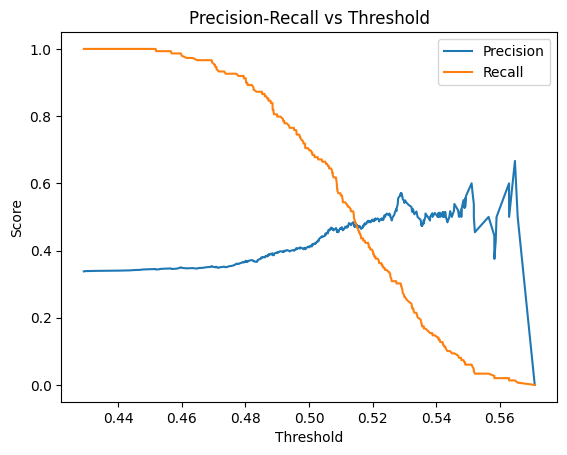

In [76]:
y_probas = lr_best.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probas)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.show()


In [77]:
y_probas = lr_best.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Apply custom threshold
y_probas_custom = (y_probas >= 0.40).astype(int)

print(f'Confusion Matrix: \n{pd.crosstab(y_test, y_probas_custom)}\n')
print(f'Classification Report: \n{classification_report(y_test, y_probas_custom)}\n')

Confusion Matrix: 
col_0          1
Malnurished     
0            292
1            149

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       292
           1       0.34      1.00      0.51       149

    accuracy                           0.34       441
   macro avg       0.17      0.50      0.25       441
weighted avg       0.11      0.34      0.17       441




/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Average precision

In [78]:
print(f'Average Precision: {average_precision_score(y_test, y_probas)}')
print(f'Average Precision Adjusted: {average_precision_score(y_test, y_probas_custom)}')

Average Precision: 0.46229007898515145
Average Precision Adjusted: 0.3378684807256236


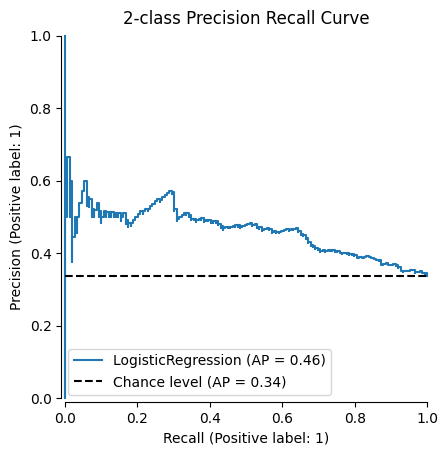

In [79]:
display = PrecisionRecallDisplay.from_estimator(
    lr_best,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
    despine = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

**Extract feature coefficient and p-value**

In [81]:
import statsmodels.api as sm

# Add intercept to feature set
X_train_with_intercept = sm.add_constant(X_train)

# Fit logistic regression model using statsmodels
logit_model = sm.Logit(y_train, X_train_with_intercept)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.610003
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Malnurished   No. Observations:                 1764
Model:                          Logit   Df Residuals:                     1727
Method:                           MLE   Df Model:                           36
Date:                Thu, 10 Apr 2025   Pseudo R-squ.:                 0.04629
Time:                        18:09:50   Log-Likelihood:                -1076.0
converged:                       True   LL-Null:                       -1128.3
Covariance Type:            nonrobust   LLR p-value:                 1.368e-08
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.7571      0.391     -1.937  

## Feature selection techniques

### Using SelectKBest with f_classif

In [82]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=10)
X_new = selector.fit_transform(X_train, y_train)

# Get the names of the selected features
selected_features = X_train.columns[selector.get_support()]

# Print the selected feature names and the shape of the transformed data
print("Selected Features:", selected_features.tolist())
print("Shape of selected features data:", X_new.shape)



Selected Features: ['Child_age', 'BMI', 'Children_under5', 'Mother_education_2', 'Wealth_index_3', 'Wealth_index_4', 'Place_residence_rural', 'Region_madhesh province', 'Ethnicity_other terai caste', 'Ethnicity_hill janajati']
Shape of selected features data: (1764, 10)


The SelectKBest method with f_classif scores each feature using the ANOVA F-test and selects the top 18 features based on these scores.

## Optional


### ROC curve


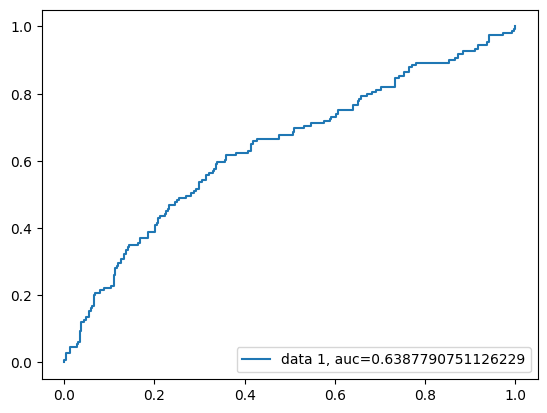

In [92]:
y_probas_custom = lr.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_probas_custom)
auc = metrics.roc_auc_score(y_test, y_probas_custom)
plt.plot(fpr,tpr,label="data 1, auc="+str(auc))
plt.legend(loc=4)
plt.show()